In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_dir = "/content/drive/MyDrive/Kuliah/ML/images/training/"
test_dir = "/content/drive/MyDrive/Kuliah/ML/images/test/"

In [4]:
# Extract all historgam feature from the dataset

# Get a normalized brightness histogram from an image
def extract_histogram(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    histogram = cv2.calcHist([hsv], [2], None, [64], [0, 256])
    histogram = histogram.flatten()
    histogram = histogram / histogram.sum()
    return histogram


# Read images from the existing training and test folders
X = []
y = []
image_paths = []

for folder in [train_dir, test_dir]:
    folder = Path(folder)
    if not folder.is_dir():
        raise FileNotFoundError(f"Dataset folder not found: {folder}")

    for class_folder in sorted(folder.iterdir()):
        if not class_folder.is_dir():
            continue

        for image_path in sorted(class_folder.iterdir()):
            if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                continue

            image = cv2.imread(str(image_path))
            if image is None:
                print(f"Skipped unreadable image: {image_path}")
                continue

            X.append(extract_histogram(image))
            y.append(class_folder.name.lower())
            image_paths.append(str(image_path))

X = np.array(X)
y = np.array(y)

if len(X) == 0:
    raise ValueError("No images found. Check your dataset paths and class folders.")

print("Total images:", len(X))
print("Histogram features:", X.shape)
print("Classes:", np.unique(y, return_counts=True))

Total images: 400
Histogram features: (400, 64)
Classes: (array(['day', 'night'], dtype='<U5'), array([200, 200]))


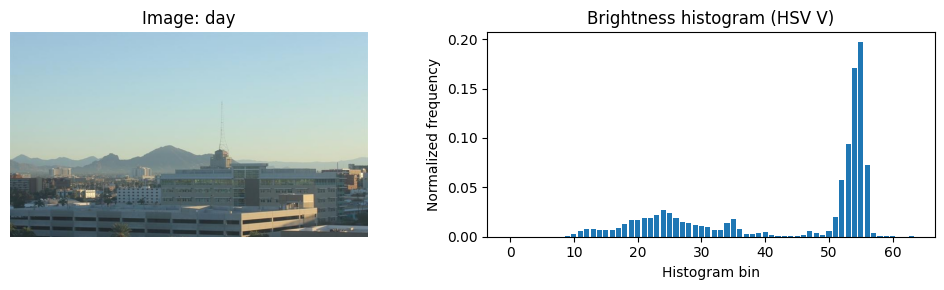

In [5]:
image = cv2.imread(image_paths[0])

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title(f"Image: {y[0]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.bar(range(64), X[0])
plt.title("Brightness histogram (HSV V)")
plt.xlabel("Histogram bin")
plt.ylabel("Normalized frequency")

plt.tight_layout()
plt.show()

In [6]:
# make 80 : 20 proportions

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 320
Testing images: 80


In [7]:
# training with rbf kernel

model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1.0, gamma="scale")
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [8]:
# Evaluate

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_accuracy:.2%}")
print(f"Testing accuracy : {test_accuracy:.2%}")
print("\nClassification report (test data):")
print(classification_report(y_test, y_test_pred, zero_division=0))

Training accuracy: 98.44%
Testing accuracy : 98.75%

Classification report (test data):
              precision    recall  f1-score   support

         day       1.00      0.97      0.99        40
       night       0.98      1.00      0.99        40

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

